In [13]:
import torch
from torchvision import datasets, transforms,models
from torch.utils.data import DataLoader,random_split,Subset
from sklearn.model_selection import train_test_split
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np 
import random
from sklearn.model_selection import train_test_split
import os
from PIL import Image

In [14]:
dataset_path = "dataset/CROP+MERGED"

train_path = dataset_path + "/train"
test_path = "dataset/test"


In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("DEVICE")
print("=" * 70)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE
Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [17]:
augmentation_list = {

    "No Augmentation": transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ToTensor()
    ]),

    "Basic": transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.Resize((150, 150)),
        transforms.ToTensor()
    ]),

    "Color": transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),
        transforms.ToTensor()
    ]),

    "Crop": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),
        transforms.ToTensor()
    ]),

    "Full without Color": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ]),

    "Full + Basic": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(10),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ]),

    "Full + Basic + Color": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.RandomHorizontalFlip(p=0.5),

        transforms.RandomRotation(10),

        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ]),

    "Full": transforms.Compose([
        transforms.RandomResizedCrop(
            size=(150, 150),
            scale=(0.7, 1.0)
        ),

        transforms.ColorJitter(
            brightness=0.3,
            contrast=0.3,
            saturation=0.3,
            hue=0.1
        ),

        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3)],
            p=0.3
        ),

        transforms.ToTensor(),

        transforms.RandomErasing(
            p=0.3,
            scale=(0.02, 0.15)
        )
    ])
}


augmentation_count = {

    "No Augmentation": 0,
    "Basic": 2,
    "Color": 1,
    "Crop": 1,
    "Full without Color": 3,
    "Full + Basic": 5,
    "Full + Basic + Color": 6,
    "Full": 4
}


test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])


seeds = [42, 10, 20]

results = []



for augmentation_name, train_transform in augmentation_list.items():

    for seed in seeds:

        print("\n" + "=" * 70)
        print("Augmentation:", augmentation_name)
        print("Seed:", seed)
        print("Training: FULL NETWORK")
        print("=" * 70)

        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)


        full_train_dataset = datasets.ImageFolder(
            train_path,
            transform=None
        )

        labels = full_train_dataset.targets


        train_indices, val_indices = train_test_split(
            range(len(full_train_dataset)),
            test_size=0.2,
            stratify=labels,
            random_state=42
        )


        train_dataset = datasets.ImageFolder(
            train_path,
            transform=train_transform
        )

        val_dataset = datasets.ImageFolder(
            train_path,
            transform=test_transform
        )


        train_dataset = Subset(
            train_dataset,
            train_indices
        )

        val_dataset = Subset(
            val_dataset,
            val_indices
        )


        train_loader = DataLoader(
            train_dataset,
            batch_size=32,
            shuffle=True,
            pin_memory=torch.cuda.is_available()
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=32,
            shuffle=False,
            pin_memory=torch.cuda.is_available()
        )


        model = models.resnet18(weights="DEFAULT")


        model.fc = nn.Linear(
            model.fc.in_features,
            8
        )

        for param in model.parameters():
            param.requires_grad = True


        
        model = model.to(device)


   

        criterion = nn.CrossEntropyLoss()


  

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=0.0001
        )


   
        best_val_accuracy = 0
        patience = 50
        counter = 0

        best_model_state = None



        for epoch in range(150):

            model.train()

            total_loss = 0


        

            for images, labels in train_loader:

                images = images.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )


                optimizer.zero_grad()


                outputs = model(images)


                loss = criterion(
                    outputs,
                    labels
                )


                loss.backward()


                optimizer.step()


                total_loss += loss.item()


            train_loss = (
                total_loss /
                len(train_loader)
            )


     

            model.eval()

            correct = 0
            total = 0
            val_total_loss = 0


            with torch.no_grad():

                for images, labels in val_loader:

                    images = images.to(
                        device,
                        non_blocking=True
                    )

                    labels = labels.to(
                        device,
                        non_blocking=True
                    )


                    outputs = model(images)


                    loss = criterion(
                        outputs,
                        labels
                    )


                    val_total_loss += loss.item()


                    _, predicted = torch.max(
                        outputs,
                        1
                    )


                    total += labels.size(0)

                    correct += (
                        predicted == labels
                    ).sum().item()


            val_loss = (
                val_total_loss /
                len(val_loader)
            )

            val_accuracy = (
                correct /
                total
            )


            print(
                f"Epoch [{epoch+1}], "
                f"Train Loss: {train_loss:.4f}, "
                f"Val Loss: {val_loss:.4f}, "
                f"Val Accuracy: {val_accuracy:.4f}"
            )


      

            if val_accuracy > best_val_accuracy:

                best_val_accuracy = val_accuracy

                counter = 0

                best_model_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model.state_dict().items()
                }


            else:

                counter += 1

                if counter >= patience:

                    print("Early stopping!")

                    break


     
        results.append({
            "augmentation": augmentation_name,
            "seed": seed,
            "best_val_accuracy": best_val_accuracy,
            "augmentation_count": augmentation_count[
                augmentation_name
            ],
            "model_state": best_model_state
        })


        print(
            f"Best Val Accuracy: "
            f"{best_val_accuracy * 100:.2f}%"
        )


best_result = results[0]


for result in results:

    if (
        result["best_val_accuracy"]
        >
        best_result["best_val_accuracy"]
    ):

        best_result = result

    elif (
        result["best_val_accuracy"]
        ==
        best_result["best_val_accuracy"]
    ):

        if (
            result["augmentation_count"]
            >
            best_result["augmentation_count"]
        ):

            best_result = result

print("\n" + "=" * 70)
print("ALL RESULTS - FULL NETWORK")
print("=" * 70)


for result in results:

    print(
        f"{result['augmentation']:25s} | "
        f"Seed: {result['seed']} | "
        f"Val: "
        f"{result['best_val_accuracy'] * 100:.2f}% | "
        f"Augmentations: "
        f"{result['augmentation_count']}"
    )

print("\n" + "=" * 70)
print("BEST MODEL - FULL NETWORK")
print("=" * 70)


print(
    f"Augmentation: "
    f"{best_result['augmentation']}"
)

print(
    f"Seed: "
    f"{best_result['seed']}"
)

print(
    f"Validation Accuracy: "
    f"{best_result['best_val_accuracy'] * 100:.2f}%"
)

print(
    f"Number of Augmentations: "
    f"{best_result['augmentation_count']}"
)



torch.save(
    best_result["model_state"],
    "BEST_MODEL_Cleaned_Dataset_FULL_NETWORK_.pth"
)


print(
    "\nBEST_MODEL_Cleaned_Dataset_FULL_NETWORK_.pth "
    "saved successfully."
)




test_dataset = datasets.ImageFolder(
    test_path,
    transform=test_transform
)


test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)


model = models.resnet18(weights=None)


model.fc = nn.Linear(
    model.fc.in_features,
    8
)


model.load_state_dict(
    torch.load(
        "BEST_MODEL_Cleaned_Dataset_FULL_NETWORK_.pth",
        map_location="cpu"
    )
)


model = model.to(device)

model.eval()


all_labels = []
all_predictions = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        outputs = model(images)


        _, predicted = torch.max(
            outputs,
            1
        )


        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )


all_labels = np.array(all_labels)

all_predictions = np.array(
    all_predictions
)


test_accuracy = (
    all_labels == all_predictions
).mean()


print("\n" + "=" * 70)
print("TEST RESULT - FULL NETWORK")
print("=" * 70)


print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)


print("\nClassification Report:")


print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)


Augmentation: No Augmentation
Seed: 42
Training: FULL NETWORK
Epoch [1], Train Loss: 0.5412, Val Loss: 0.1880, Val Accuracy: 0.9304
Epoch [2], Train Loss: 0.0695, Val Loss: 0.1611, Val Accuracy: 0.9495
Epoch [3], Train Loss: 0.0196, Val Loss: 0.1417, Val Accuracy: 0.9574
Epoch [4], Train Loss: 0.0093, Val Loss: 0.1531, Val Accuracy: 0.9562
Epoch [5], Train Loss: 0.0046, Val Loss: 0.1267, Val Accuracy: 0.9585
Epoch [6], Train Loss: 0.0046, Val Loss: 0.1369, Val Accuracy: 0.9574
Epoch [7], Train Loss: 0.0109, Val Loss: 0.1581, Val Accuracy: 0.9562
Epoch [8], Train Loss: 0.0199, Val Loss: 0.2040, Val Accuracy: 0.9484
Epoch [9], Train Loss: 0.0390, Val Loss: 0.3124, Val Accuracy: 0.9192
Epoch [10], Train Loss: 0.0452, Val Loss: 0.1616, Val Accuracy: 0.9574
Epoch [11], Train Loss: 0.0181, Val Loss: 0.1597, Val Accuracy: 0.9596
Epoch [12], Train Loss: 0.0121, Val Loss: 0.1643, Val Accuracy: 0.9540
Epoch [13], Train Loss: 0.0057, Val Loss: 0.1678, Val Accuracy: 0.9574
Epoch [14], Train Loss:

In [ ]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    8
)

model.load_state_dict(
    torch.load(
        "BEST_MODEL_Cleaned_Dataset_FULL_NETWORK_.pth",
        map_location="cpu"
    )
)

model = model.to(device)
model.eval()


all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

test_accuracy = (all_labels == all_predictions).mean()

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

Test Accuracy: 98.25%

Classification Report:
              precision    recall  f1-score   support

   ambulance       1.00      1.00      1.00        50
     autobus       1.00      1.00      1.00        50
      kamyun       1.00      0.88      0.94        50
    kamyunet       0.89      1.00      0.94        50
     minibus       1.00      1.00      1.00        50
      savari       1.00      0.98      0.99        50
        taxi       1.00      1.00      1.00        50
       vanet       0.98      1.00      0.99        50

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



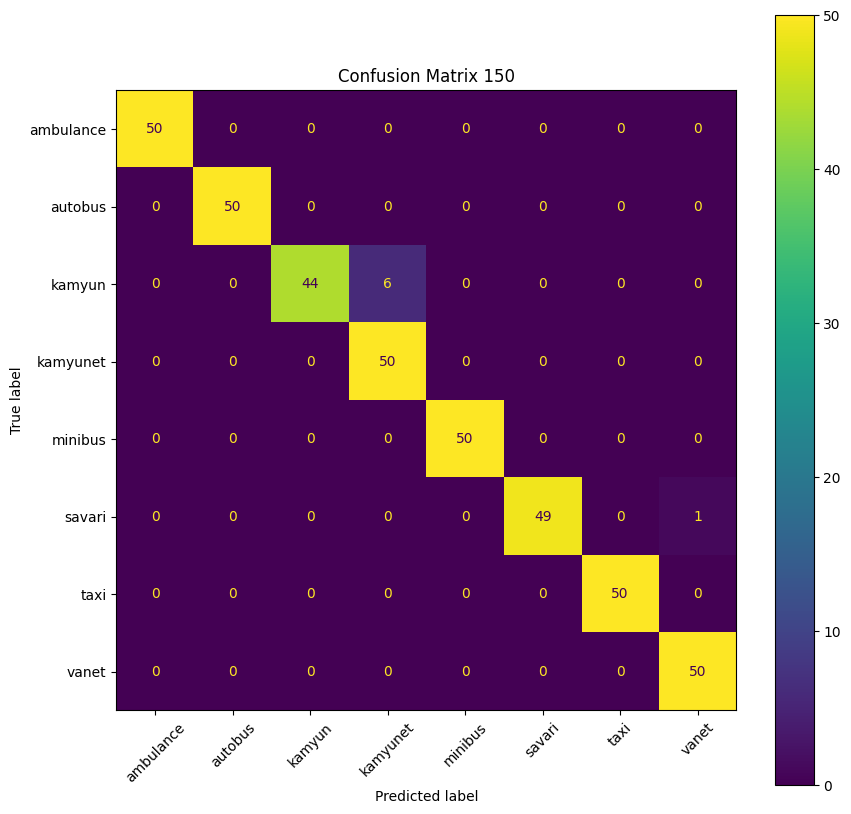

In [20]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(f"Confusion Matrix {images.shape[-1]}")
plt.show()

In [25]:
wrong_predictions = []

start_index = 0

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            dim=1
        )

        for i in range(len(labels)):

            if predicted[i] != labels[i]:

                wrong_predictions.append({
                    "index": start_index + i,
                    "true_class": test_dataset.classes[
                        labels[i].item()
                    ],
                    "predicted_class": test_dataset.classes[
                        predicted[i].item()
                    ],
                    "confidence": confidence[i].item()
                })

        start_index += len(labels)


print("=" * 80)
print("WRONG PREDICTIONS")
print("=" * 80)

print(
    f"Number of wrong predictions: "
    f"{len(wrong_predictions)}"
)

for item in wrong_predictions:

    print(
        f"Index: {item['index']} | "
        f"True: {item['true_class']} | "
        f"Predicted: {item['predicted_class']} | "
        f"Confidence: {item['confidence'] * 100:.2f}%"
    )

WRONG PREDICTIONS
Number of wrong predictions: 7
Index: 108 | True: kamyun | Predicted: kamyunet | Confidence: 99.72%
Index: 112 | True: kamyun | Predicted: kamyunet | Confidence: 99.99%
Index: 122 | True: kamyun | Predicted: kamyunet | Confidence: 63.08%
Index: 127 | True: kamyun | Predicted: kamyunet | Confidence: 94.49%
Index: 129 | True: kamyun | Predicted: kamyunet | Confidence: 99.82%
Index: 143 | True: kamyun | Predicted: kamyunet | Confidence: 98.48%
Index: 287 | True: savari | Predicted: vanet | Confidence: 66.45%


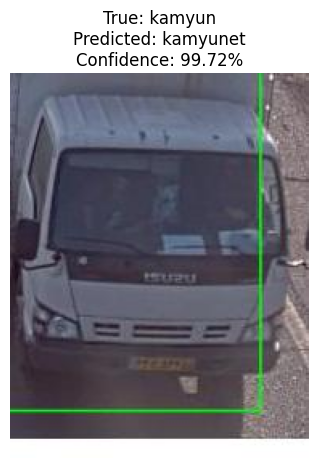

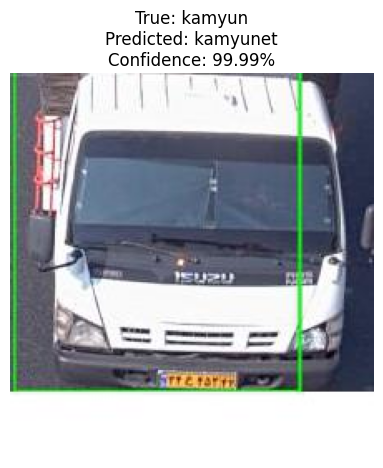

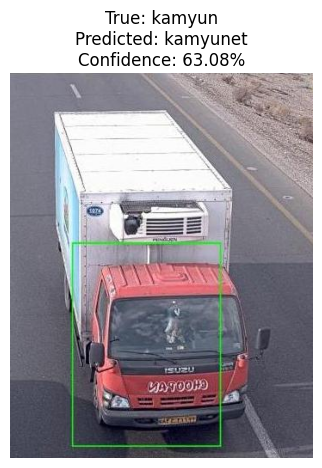

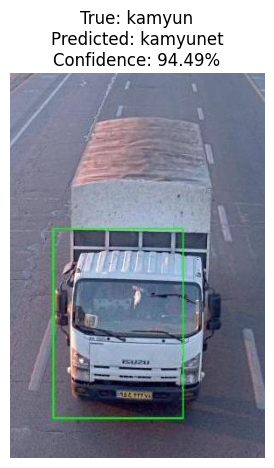

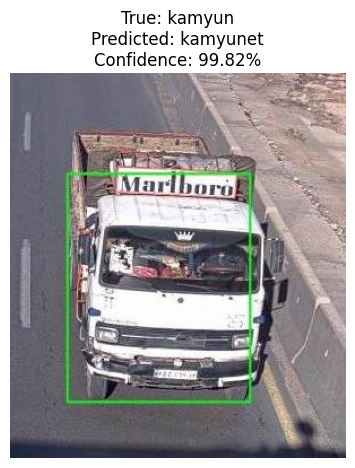

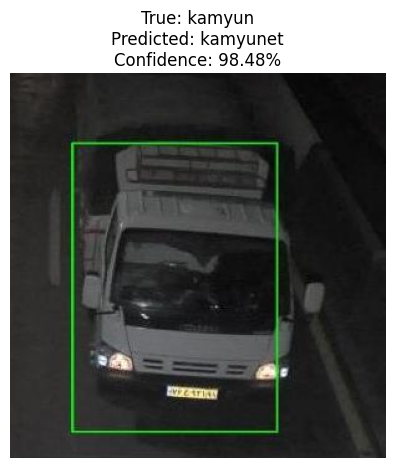

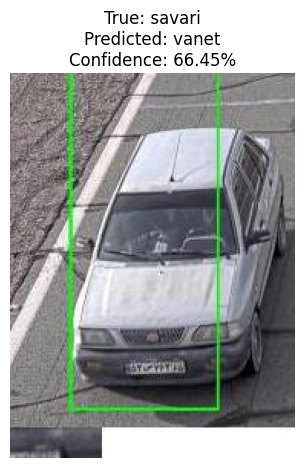

In [ ]:
for item in wrong_predictions:

    index = item["index"]

    image_path, _ = test_dataset.samples[index]

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(5, 5))

    plt.imshow(image)

    plt.title(
        f"True: {item['true_class']}\n"
        f"Predicted: {item['predicted_class']}\n"
        f"Confidence: {item['confidence'] * 100:.2f}%"
    )

    plt.axis("off")

    plt.show()

In [28]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(
    model.fc.in_features,
    8
)

model.load_state_dict(
    torch.load(
        "BEST_MODEL_Cleaned_Dataset_FULL_NETWORK.pth",
        map_location="cpu"
    )
)

model = model.to(device)
model.eval()


all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

test_accuracy = (all_labels == all_predictions).mean()

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

Test Accuracy: 98.50%

Classification Report:
              precision    recall  f1-score   support

   ambulance       1.00      0.96      0.98        50
     autobus       1.00      1.00      1.00        50
      kamyun       0.98      0.94      0.96        50
    kamyunet       0.96      0.98      0.97        50
     minibus       0.96      1.00      0.98        50
      savari       1.00      1.00      1.00        50
        taxi       1.00      1.00      1.00        50
       vanet       0.98      1.00      0.99        50

    accuracy                           0.98       400
   macro avg       0.99      0.98      0.98       400
weighted avg       0.99      0.98      0.98       400



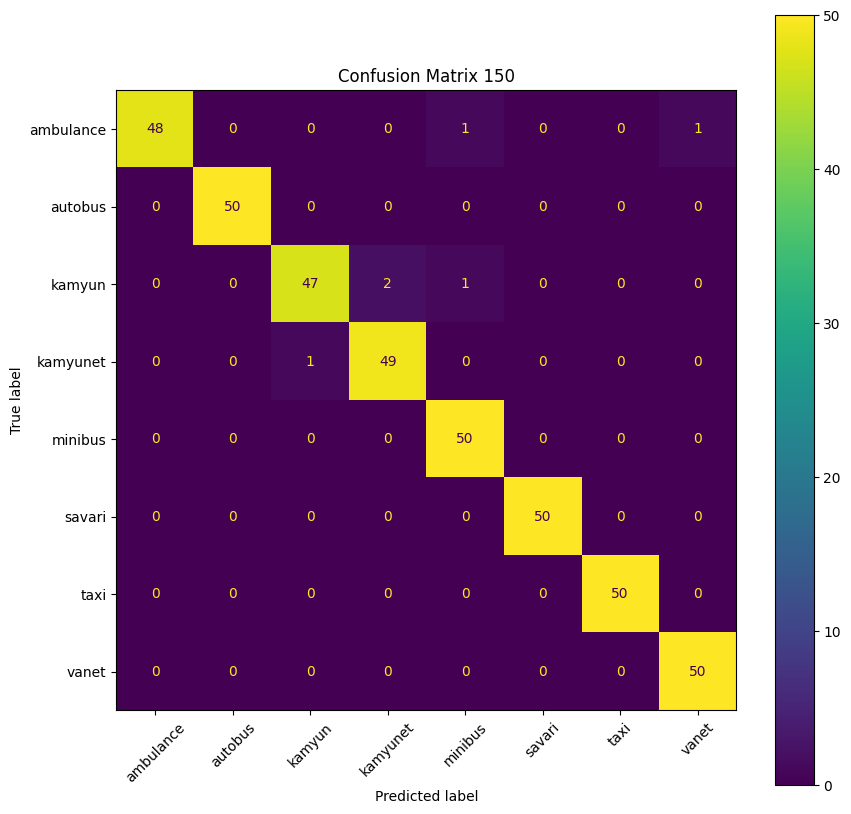

In [29]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title(f"Confusion Matrix {images.shape[-1]}")
plt.show()

In [30]:
wrong_predictions = []

start_index = 0

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            dim=1
        )

        for i in range(len(labels)):

            if predicted[i] != labels[i]:

                wrong_predictions.append({
                    "index": start_index + i,
                    "true_class": test_dataset.classes[
                        labels[i].item()
                    ],
                    "predicted_class": test_dataset.classes[
                        predicted[i].item()
                    ],
                    "confidence": confidence[i].item()
                })

        start_index += len(labels)


print("=" * 80)
print("WRONG PREDICTIONS")
print("=" * 80)

print(
    f"Number of wrong predictions: "
    f"{len(wrong_predictions)}"
)

for item in wrong_predictions:

    print(
        f"Index: {item['index']} | "
        f"True: {item['true_class']} | "
        f"Predicted: {item['predicted_class']} | "
        f"Confidence: {item['confidence'] * 100:.2f}%"
    )

WRONG PREDICTIONS
Number of wrong predictions: 6
Index: 19 | True: ambulance | Predicted: vanet | Confidence: 45.02%
Index: 40 | True: ambulance | Predicted: minibus | Confidence: 46.64%
Index: 112 | True: kamyun | Predicted: kamyunet | Confidence: 99.96%
Index: 143 | True: kamyun | Predicted: kamyunet | Confidence: 99.99%
Index: 147 | True: kamyun | Predicted: minibus | Confidence: 62.83%
Index: 181 | True: kamyunet | Predicted: kamyun | Confidence: 86.65%


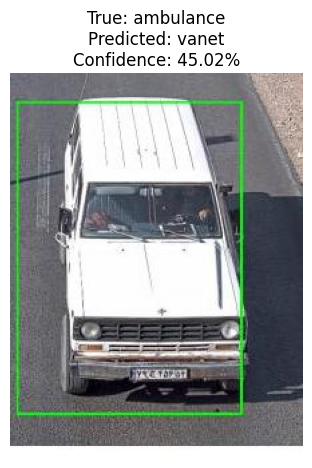

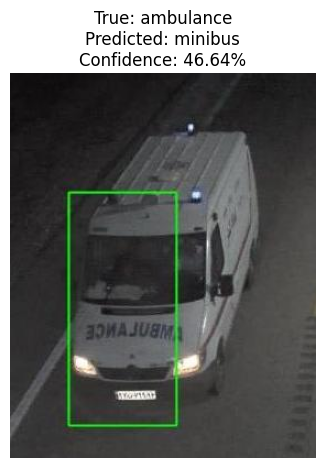

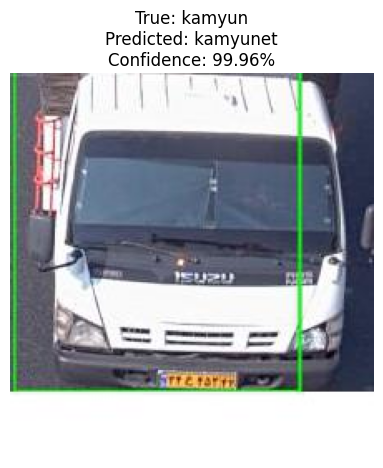

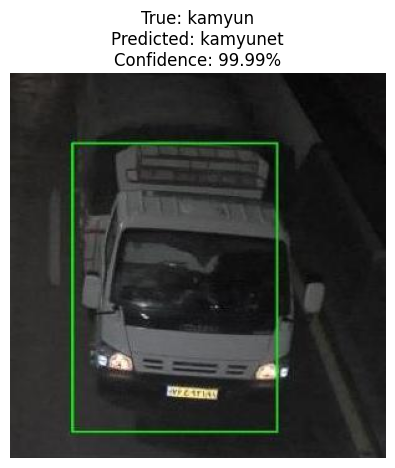

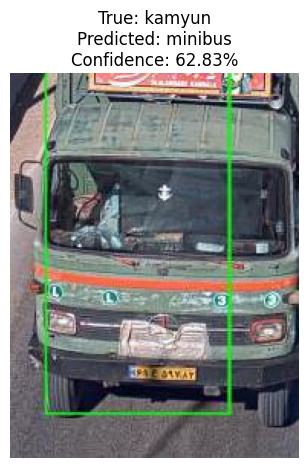

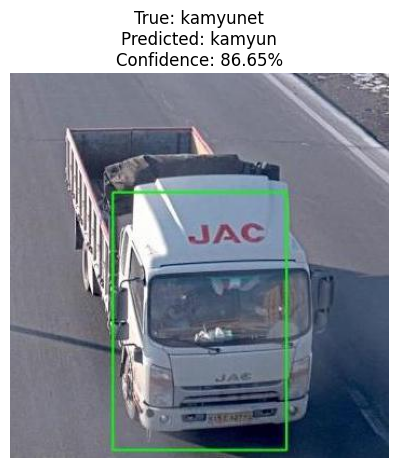

In [31]:
for item in wrong_predictions:

    index = item["index"]

    image_path, _ = test_dataset.samples[index]

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(5, 5))

    plt.imshow(image)

    plt.title(
        f"True: {item['true_class']}\n"
        f"Predicted: {item['predicted_class']}\n"
        f"Confidence: {item['confidence'] * 100:.2f}%"
    )

    plt.axis("off")

    plt.show()